#  Black Friday Logistics Nightmare

**The Problem:**
Every Black Friday, stores struggle - products run out of stock, warehouses get overwhelmed, and deliveries are delayed. We use data to answer: *Who is buying? What are they buying? How much are they spending?* - so the store can plan better next time.

## Import Libraries
We load all the tools we need at the start so we don't have to repeat it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

---
## Week 1 — Load the Data

Before any analysis, we load the dataset and check its basic shape — how many rows, how many columns, and what each column is called.

In [2]:
# We load the CSV file into a DataFrame

df = pd.read_csv('BlackFriday dataset.csv')

# .shape gives us (number of rows, number of columns)
print(f"Number of transactions : {df.shape[0]:,}")
print(f"Number of columns      : {df.shape[1]}")
print()

print("Columns available:")
for col in df.columns:
    print(f"  • {col}")

Number of transactions : 550,068
Number of columns      : 12

Columns available:
  • User_ID
  • Product_ID
  • Gender
  • Age
  • Occupation
  • City_Category
  • Stay_In_Current_City_Years
  • Marital_Status
  • Product_Category_1
  • Product_Category_2
  • Product_Category_3
  • Purchase


In [3]:
# .head() shows the first 5 rows of the dataset

df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
# .dtypes tells us how each column is stored in memory
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

---
## Week 2 

Which columns have **missing values** and how many

What the **min, max, and average** values look like

How many **unique values** are in each column

This is our "First Impression Report"  understanding the data before touching it.

In [5]:
# We check how many values are missing in each column
# Missing values mean we don't have complete information for those rows
# We need to know this before cleaning — different columns need different fixes

# isnull() marks each missing cell as True
# .sum() counts the True values per column
# We also calculate the percentage so we know how serious each gap is

missing_count   = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

# Combine into one table and only show columns that actually have gaps
report = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percent})
print(report[report['Missing Count'] > 0])
print()
print("What this means:")
print("Product_Category_2 is missing for 1 in 3 rows")
print("Product_Category_3 is missing for 7 in 10 rows")
print()
print("Logistics insight:")
print("Most products belong to only ONE category, not two or three.")
print("This tells us most Black Friday orders are single-category shipments — simpler to pack.")
print("The ones with 2 or 3 categories are combo/bundle orders that need extra handling.")

                    Missing Count  Missing %
Product_Category_2         173638      31.57
Product_Category_3         383247      69.67

What this means:
Product_Category_2 is missing for 1 in 3 rows
Product_Category_3 is missing for 7 in 10 rows

Logistics insight:
Most products belong to only ONE category, not two or three.
This tells us most Black Friday orders are single-category shipments — simpler to pack.
The ones with 2 or 3 categories are combo/bundle orders that need extra handling.


In [6]:
# .describe() gives us a quick statistical summary of every number column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,550068.0,1.003029e+06,1727.591586,1000001.0,1001516.0,1003077.0,1004478.0,1006040.0
Occupation,550068.0,8.076707e+00,6.522660,0.0,2.0,7.0,14.0,20.0
Marital_Status,550068.0,4.096530e-01,0.491770,0.0,0.0,0.0,1.0,1.0
Product_Category_1,550068.0,5.404270e+00,3.936211,1.0,1.0,5.0,8.0,20.0
Product_Category_2,376430.0,9.842329e+00,5.086590,2.0,5.0,9.0,15.0,18.0
Product_Category_3,166821.0,1.266824e+01,4.125338,3.0,9.0,14.0,16.0,18.0
Purchase,550068.0,9.263969e+03,5023.065394,12.0,5823.0,8047.0,12054.0,23961.0


In [7]:
# For text columns, we want to know how many different values exist
# This helps us understand what categories we are dealing with
for col in df.select_dtypes('object').columns:
    print(f"{col}:")
    print(f"  Number of unique values : {df[col].nunique()}")
    print(f"  What they look like     : {list(df[col].unique()[:8])}")
    print()

Product_ID:
  Number of unique values : 3631
  What they look like     : ['P00069042', 'P00248942', 'P00087842', 'P00085442', 'P00285442', 'P00193542', 'P00184942', 'P00346142']

Gender:
  Number of unique values : 2
  What they look like     : ['F', 'M']

Age:
  Number of unique values : 7
  What they look like     : ['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']

City_Category:
  Number of unique values : 3
  What they look like     : ['A', 'C', 'B']

Stay_In_Current_City_Years:
  Number of unique values : 5
  What they look like     : ['2', '4+', '3', '1', '0']



---
## Week 3 

Raw data always has problems. This week we fix two things:
1. **Missing values** — we cannot just delete those rows because that would remove 70% of our data
2. **Outliers** — we detect extreme values and decide what to do with them

### Why Do We Keep the Outliers Instead of Removing Them?

They represent real business events:

- A customer spending ₹20,000 in one go is not a mistake, they are a real high-value bulk buyer
- If we delete them, we lose our most valuable customer information

In [8]:
# We always work on a copy of the original data
# This way if we make a mistake, we can start fresh from df without reloading the file
df_clean = df.copy()

# Fill missing values in Product_Category_2 and 3 with 0
# Why 0? Because in this dataset, missing means the product simply has no second or third category
# It is not a data entry error the value is just not applicable
# 0 works because all real category codes are between 1 and 18, so 0 will never be confused with a real category

# We do NOT delete these rows
# If we deleted every row with a missing Category_3, we would lose 70% of our entire dataset
# That would make our analysis useless

df_clean['Product_Category_2'] = df_clean['Product_Category_2'].fillna(0)
df_clean['Product_Category_3'] = df_clean['Product_Category_3'].fillna(0)

print("Missing values after filling:")
print(df_clean.isnull().sum())
print()
print("No missing values left. Every row is now complete.")

Missing values after filling:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

No missing values left. Every row is now complete.


### Outlier Check Purchase Amount
The box shows the middle 50% of spending. The red line is the median. Dots above the top whisker are the high-value buyers we are keeping.

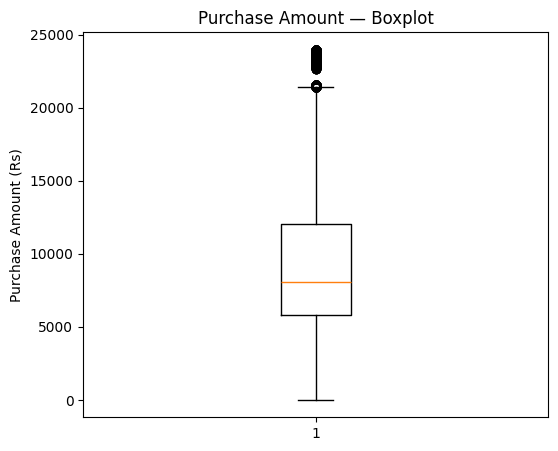

In [9]:
# A boxplot is the best way to spot outliers visually
# The BOX covers the middle 50% of values — this is the normal range
# We are looking at Purchase first because it is our most important column

plt.figure(figsize=(6,5))
plt.boxplot(df_clean['Purchase'])

plt.title('Purchase Amount — Boxplot')
plt.ylabel('Purchase Amount (Rs)')
plt.show()

Most customers spend roughly between Rs 5,000 and Rs 12,000.

Points above the top whisker represent customers who spent much more than average.

Why we are keeping these outliers:
They are real high-spending customers, not data errors.
Removing them would remove important purchasing behavior.

Logistics insight:
High-spending customers place larger orders.
They may require faster packing and dedicated fulfilment lanes during Black Friday.

### Outlier Check Product Category 1
Shows the spread of category numbers to see which ones dominate.

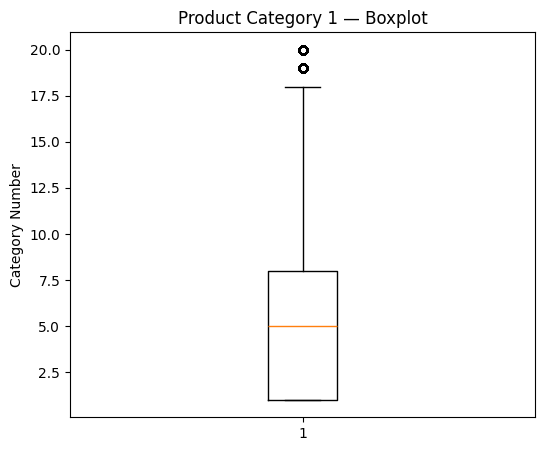

In [10]:
plt.figure(figsize=(6,5))
plt.boxplot(df_clean['Product_Category_1'])

plt.title('Product Category 1 — Boxplot')
plt.ylabel('Category Number')
plt.show()

The values stay within the expected range — no unexpected codes.
Most products cluster in categories 1 to 8.

Logistics insight:

Categories 1 to 8 dominate the order volume.

These product zones in the warehouse will have the most traffic on Black Friday.

They need the most picking staff and the widest lanes.

In [11]:
# The Z-score is a mathematical way to measure how extreme a value is
# It tells us: how many standard deviations away from the average is this value?

# A Z-score above 3 means the value is so far from average that it is considered a statistical outlier
# We use this to count how many such extreme values exist in the Purchase column

z        = np.abs(stats.zscore(df_clean['Purchase']))
outliers = df_clean[z > 3]

print(f"Number of rows with Z-score above 3 : {len(outliers)}")
print(f"As a percentage of all transactions  : {len(outliers)/len(df_clean)*100:.2f}%")
print()

# Winsorize — this is how we handle the outliers without deleting them
# We cap the Purchase values at the 1st percentile (bottom) and 99th percentile (top)
# Any value below the 1st percentile gets raised to that level
# Any value above the 99th percentile gets lowered to that level
# Every row stays — we just limit how extreme the values can be

# This protects our averages and models from being distorted by extreme values
# while keeping all the information about WHO those customers are

low  = df_clean['Purchase'].quantile(0.01)
high = df_clean['Purchase'].quantile(0.99)
df_clean['Purchase'] = df_clean['Purchase'].clip(lower=low, upper=high)

print(f"Purchase is now capped between Rs {low:.0f} and Rs {high:.0f}")
print()
print("All rows are still in the dataset — no data was deleted.")
print()
print("Logistics insight:")
print("Our demand forecasts will no longer be pulled upward by a handful of massive orders.")
print("This gives us more realistic stock estimates for the warehouse.")

Number of rows with Z-score above 3 : 0
As a percentage of all transactions  : 0.00%

Purchase is now capped between Rs 587 and Rs 20665

All rows are still in the dataset — no data was deleted.

Logistics insight:
Our demand forecasts will no longer be pulled upward by a handful of massive orders.
This gives us more realistic stock estimates for the warehouse.


---
## Week 4 — Explore the Data (EDA)

EDA stands for Exploratory Data Analysis. We draw graphs to understand patterns in the data.

- **Univariate** — looking at one column at a time (who is shopping?)
- **Bivariate** — comparing two columns (does city affect spending?)
- **Correlation** — do variables move together or in opposite directions?

Every graph answers a question the logistics team needs to know.

### Gender Distribution
How many male vs female shoppers are there?

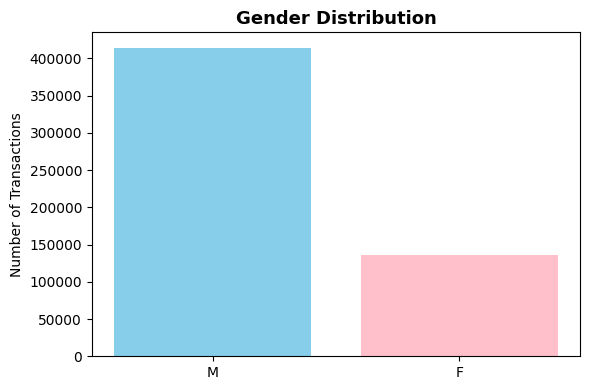

About 75% of Black Friday transactions are from male shoppers.

Logistics insight:
Male shoppers dominate this sale event.
Products popular with men — electronics, gadgets, sports equipment —
will see the highest demand and need the most stock on Black Friday.


In [12]:
# We count how many transactions belong to each gender
# .value_counts() counts occurrences of each unique value
# This is the simplest way to see the gender split in our data

counts = df_clean['Gender'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['skyblue', 'pink'])
plt.title('Gender Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("About 75% of Black Friday transactions are from male shoppers.")
print()
print("Logistics insight:")
print("Male shoppers dominate this sale event.")
print("Products popular with men — electronics, gadgets, sports equipment —")
print("will see the highest demand and need the most stock on Black Friday.")

### Age Group Distribution
Which age group shops the most?

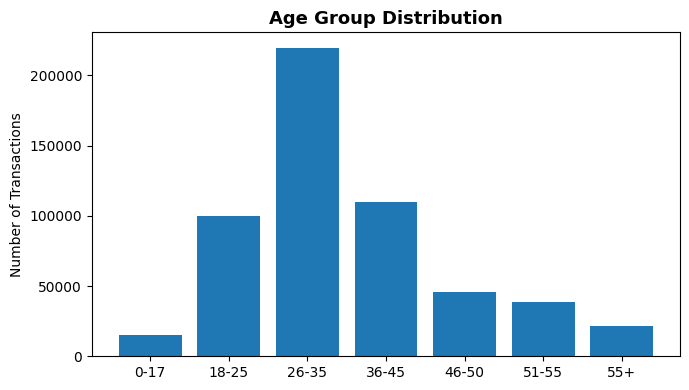

The 26-35 age group has the most transactions by a significant margin.

Logistics insight:
This age group is in their peak earning and spending years.
Whatever they buy most frequently needs to be stocked in the highest quantities.
Warehouse picking lanes for those products need the fastest throughput.


In [13]:
# .sort_index() sorts the age groups in order (0-17, 18-25, 26-35, etc.)
# Without this, the bars would appear in random order which is hard to read

counts = df_clean['Age'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values)
plt.title('Age Group Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("The 26-35 age group has the most transactions by a significant margin.")
print()
print("Logistics insight:")
print("This age group is in their peak earning and spending years.")
print("Whatever they buy most frequently needs to be stocked in the highest quantities.")
print("Warehouse picking lanes for those products need the fastest throughput.")

### City Category Distribution
Which city type has the most shoppers?

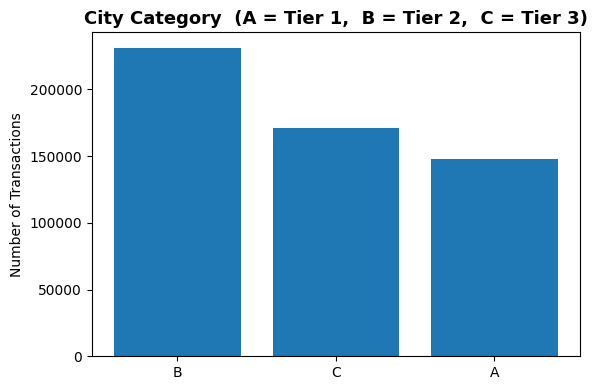

City B has the most transactions — more than City A and City C combined.

Logistics insight:
Tier-2 cities generate the most order volume on Black Friday.
The distribution centre serving these cities will face the heaviest load.
It needs the most workers, the most stock, and the most delivery vehicles.


In [14]:
counts = df_clean['City_Category'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title('City Category  (A = Tier 1,  B = Tier 2,  C = Tier 3)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("City B has the most transactions — more than City A and City C combined.")
print()
print("Logistics insight:")
print("Tier-2 cities generate the most order volume on Black Friday.")
print("The distribution centre serving these cities will face the heaviest load.")
print("It needs the most workers, the most stock, and the most delivery vehicles.")

### Marital Status Distribution

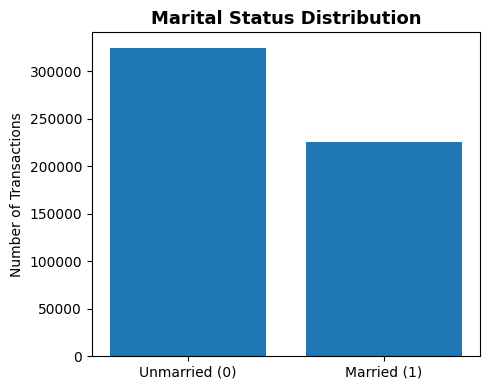

There are more unmarried shoppers than married ones in this dataset.
We will check in the bivariate section whether marital status affects how much people spend.


In [15]:
counts = df_clean['Marital_Status'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(['Unmarried (0)', 'Married (1)'], counts.values)
plt.title('Marital Status Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("There are more unmarried shoppers than married ones in this dataset.")
print("We will check in the bivariate section whether marital status affects how much people spend.")

### Product Category 1 — Which Categories Sell the Most?

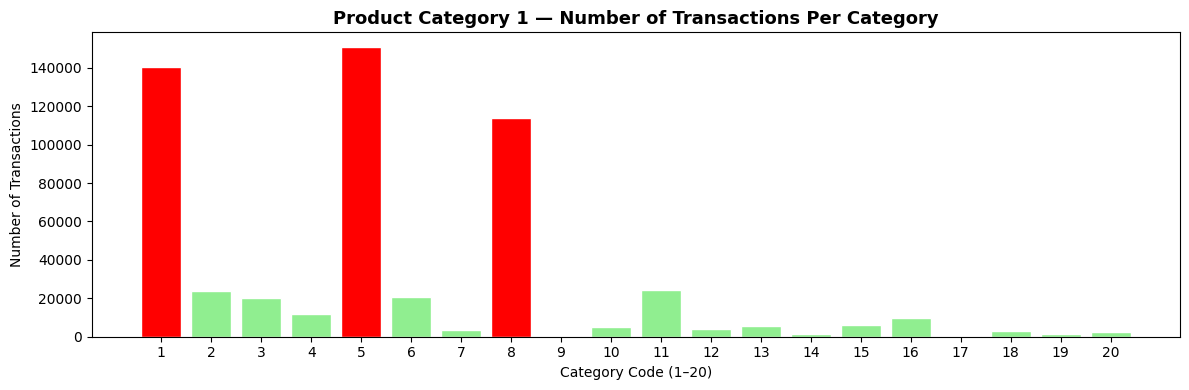

Red bars = the 3 most purchased product categories.

Logistics insight:
These three categories generate the most picking and packing activity in the warehouse.
On Black Friday, every second counts — these zones need the fastest staff,
the most floor space, and automatic restock alerts when stock runs low.


In [16]:
# .sort_index() shows categories in numerical order (1, 2, 3 ... 20)
# We highlight the top 3 in red so they stand out immediately

counts   = df_clean['Product_Category_1'].value_counts().sort_index()
top3_idx = counts.nlargest(3).index

# Build a colour list — red for top 3, blue for the rest
bar_colors = ['red' if i in top3_idx else 'lightgreen' for i in counts.index]

plt.figure(figsize=(12, 4))
plt.bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='white')
plt.title('Product Category 1 — Number of Transactions Per Category', fontsize=13, fontweight='bold')
plt.xlabel('Category Code (1–20)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("Red bars = the 3 most purchased product categories.")
print()
print("Logistics insight:")
print("These three categories generate the most picking and packing activity in the warehouse.")
print("On Black Friday, every second counts — these zones need the fastest staff,")
print("the most floor space, and automatic restock alerts when stock runs low.")

### Purchase Amount Distribution
How much do people spend? Is the spending evenly spread or skewed to one side?

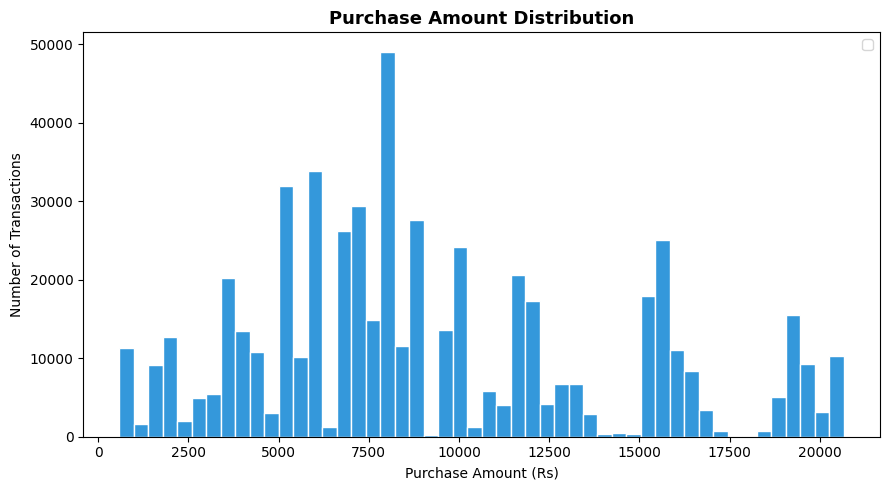

Skewness value = 0.57
A positive skewness means the histogram tail stretches to the right.

The mean is higher than the median because a few very large purchases pull the average up.

Logistics insight:
We cannot plan a single standard fulfilment process for everyone.
The high spenders at the right end of this histogram place bigger, heavier orders.
They need a separate express lane — faster handling, priority dispatch, premium packaging.


In [17]:
# A histogram shows how purchase amounts are distributed across all transactions
# bins=50 means we split the range into 50 equal buckets and count how many transactions fall in each

plt.figure(figsize=(9, 5))
plt.hist(df_clean['Purchase'], bins=50, color='#3498DB', edgecolor='white')
plt.title('Purchase Amount Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Purchase Amount (Rs)')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Skewness value = {df_clean['Purchase'].skew():.2f}")
print("A positive skewness means the histogram tail stretches to the right.")
print()
print("The mean is higher than the median because a few very large purchases pull the average up.")
print()
print("Logistics insight:")
print("We cannot plan a single standard fulfilment process for everyone.")
print("The high spenders at the right end of this histogram place bigger, heavier orders.")
print("They need a separate express lane — faster handling, priority dispatch, premium packaging.")

### Gender vs Purchase Amount
Do men and women spend differently per transaction?

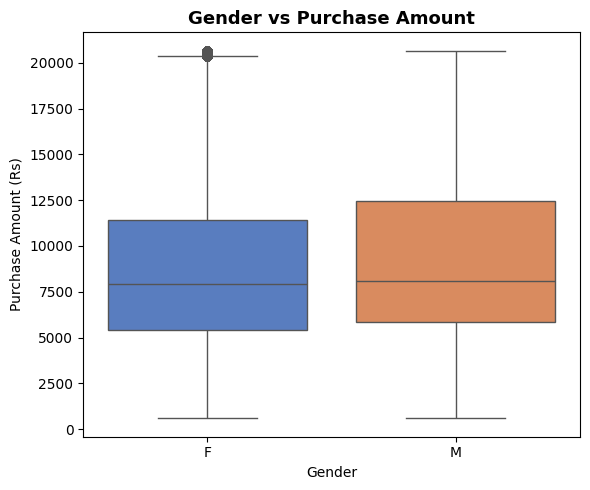

Male shoppers spend slightly more per transaction than female shoppers.

Logistics insight:
Male-targeted products have both higher volume AND higher spend per order.
This means the male product zone in the warehouse carries more weight (literally) —
heavier items, bigger boxes, and higher revenue per shipment.


In [18]:
# A boxplot here compares the Purchase distribution for each gender group
# The box shows the middle 50% of spending for that group
# The line inside is the median
# If one group's box is higher than the other, that group spends more on average

plt.figure(figsize=(6, 5))
sns.boxplot(data=df_clean, x='Gender', y='Purchase', palette='muted', order=['F', 'M'])
plt.title('Gender vs Purchase Amount', fontsize=13, fontweight='bold')
plt.ylabel('Purchase Amount (Rs)')
plt.tight_layout()
plt.show()

print("Male shoppers spend slightly more per transaction than female shoppers.")
print()
print("Logistics insight:")
print("Male-targeted products have both higher volume AND higher spend per order.")
print("This means the male product zone in the warehouse carries more weight (literally) —")
print("heavier items, bigger boxes, and higher revenue per shipment.")

### Age Group vs Purchase Amount
Does your age affect how much you spend?

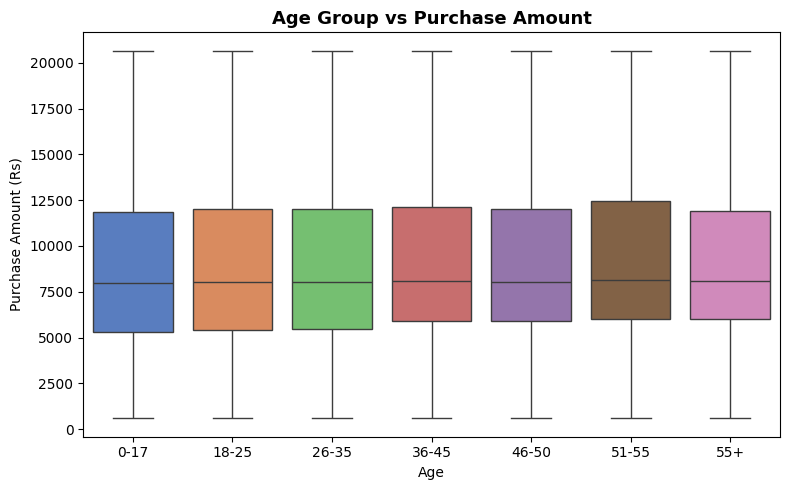

The boxes look similar in height across all age groups.
No single age group spends dramatically more than the others.

Logistics insight:
Age alone is not a reliable guide for how much stock to allocate to any group.
We need to combine age with other variables like city and product category
to get meaningful predictions — which is what we do in Week 7 with PCA.


In [19]:
# sorted() puts the age groups in logical order so the chart reads left to right from youngest to oldest
# This makes it much easier to see if spending increases or decreases with age

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Age', y='Purchase', palette='muted',order=sorted(df_clean['Age'].unique()))
plt.title('Age Group vs Purchase Amount', fontsize=13, fontweight='bold')
plt.ylabel('Purchase Amount (Rs)')
plt.tight_layout()
plt.show()

print("The boxes look similar in height across all age groups.")
print("No single age group spends dramatically more than the others.")
print()
print("Logistics insight:")
print("Age alone is not a reliable guide for how much stock to allocate to any group.")
print("We need to combine age with other variables like city and product category")
print("to get meaningful predictions — which is what we do in Week 7 with PCA.")

### City Category vs Purchase Amount
Do people in bigger vs smaller cities spend differently?

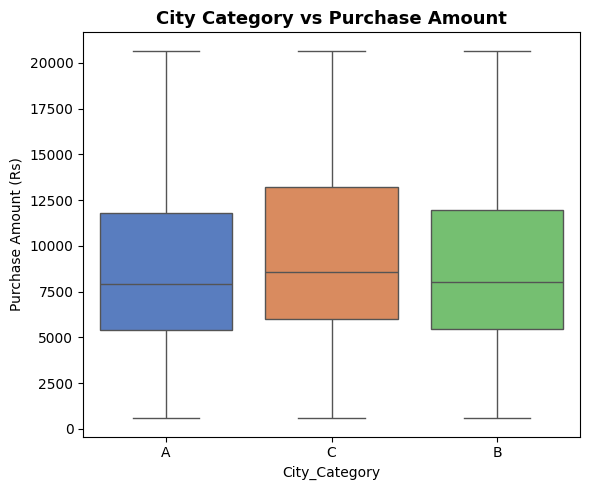

City C (Tier-3, smaller cities) has the highest median purchase amount.

Logistics insight:
City C shoppers place fewer orders overall but spend more per order.
Tier-3 city warehouses should stock more premium and expensive products
even though their total order volume is lower than City B.


In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_clean, x='City_Category', y='Purchase', palette='muted')
plt.title('City Category vs Purchase Amount', fontsize=13, fontweight='bold')
plt.ylabel('Purchase Amount (Rs)')
plt.tight_layout()
plt.show()

print("City C (Tier-3, smaller cities) has the highest median purchase amount.")
print()
print("Logistics insight:")
print("City C shoppers place fewer orders overall but spend more per order.")
print("Tier-3 city warehouses should stock more premium and expensive products")
print("even though their total order volume is lower than City B.")

### Occupation vs Purchase Amount
Do certain job types spend more?

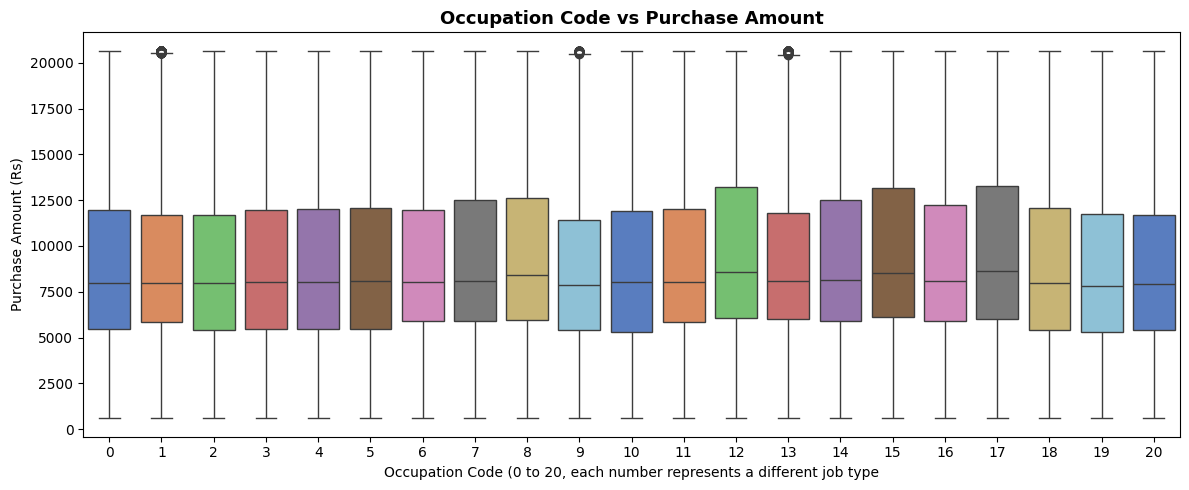

Some occupation groups have higher median spending than others.
The boxes for certain codes sit noticeably higher on the chart.

Logistics insight:
If we know which occupation codes spend the most, we can flag those customers
for VIP treatment — faster delivery, better packaging, priority dispatch.
This reduces complaints from the most valuable customer segments on Black Friday.


In [21]:
# Occupation has 21 different codes (0 to 20)
# We use a boxplot to compare how much each occupation group spends
# This helps us identify which job categories are the highest spenders

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x='Occupation', y='Purchase', palette='muted')
plt.title('Occupation Code vs Purchase Amount', fontsize=13, fontweight='bold')
plt.ylabel('Purchase Amount (Rs)')
plt.xlabel('Occupation Code (0 to 20, each number represents a different job type')
plt.tight_layout()
plt.show()

print("Some occupation groups have higher median spending than others.")
print("The boxes for certain codes sit noticeably higher on the chart.")
print()
print("Logistics insight:")
print("If we know which occupation codes spend the most, we can flag those customers")
print("for VIP treatment — faster delivery, better packaging, priority dispatch.")
print("This reduces complaints from the most valuable customer segments on Black Friday.")

### Correlation Matrix

This heatmap shows how strongly every column relates to every other column.

In [22]:
# The correlation formula only works with numbers
# But we have text columns like Gender (F/M) and Age (26-35)
# We temporarily convert them to numbers just for this correlation calculation

# LabelEncoder converts each unique text value to a number
df_corr = df_clean.copy()
le = LabelEncoder()

for col in ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Select only the columns we want to include in the correlation matrix
num_cols = ['Gender', 'Age', 'Occupation', 'City_Category',
            'Stay_In_Current_City_Years', 'Marital_Status',
            'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

corr = df_corr[num_cols].corr(numeric_only=True)

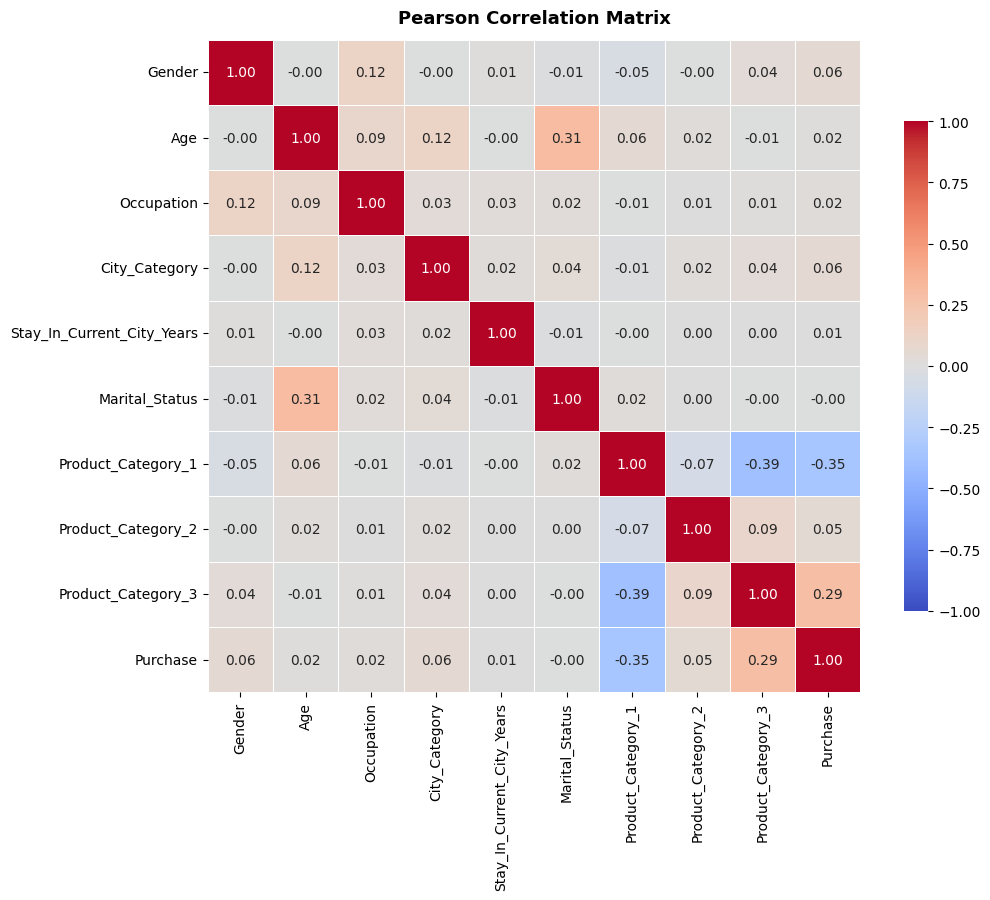

look at the Purchase row or column:

Product_Category_1 has a moderate NEGATIVE correlation with Purchase.
Lower category number = more expensive product.
Categories 1, 2, 3 are the high-value items in this store.
Logistics insight: these need secure storage zones and careful handling.

Product_Category_2 and Product_Category_3 are positively correlated with each other.
They tend to appear in the same order — meaning they are often bought together.
Logistics insight: build a bundle-picking station for these two categories.

Demographics like Gender and Age show weak correlation with Purchase individually.
No single column is a strong enough predictor on its own.
Logistics insight: we need a combined model — which is what PCA does in Week 7.


In [23]:
# A heatmap makes the correlation matrix easy to read visually
# Each cell shows the correlation between two columns as a number and a colour

# annot=True prints the actual numbers inside each cell
# fmt='.2f' means show 2 decimal places

plt.figure(figsize=(11, 9))

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.75})

plt.title('Pearson Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("look at the Purchase row or column:")
print()
print("Product_Category_1 has a moderate NEGATIVE correlation with Purchase.")
print("Lower category number = more expensive product.")
print("Categories 1, 2, 3 are the high-value items in this store.")
print("Logistics insight: these need secure storage zones and careful handling.")
print()
print("Product_Category_2 and Product_Category_3 are positively correlated with each other.")
print("They tend to appear in the same order — meaning they are often bought together.")
print("Logistics insight: build a bundle-picking station for these two categories.")
print()
print("Demographics like Gender and Age show weak correlation with Purchase individually.")
print("No single column is a strong enough predictor on its own.")
print("Logistics insight: we need a combined model — which is what PCA does in Week 7.")

We show key numbers from the cleaned dataset and a summary dashboard with the most important insights for the logistics team.

### Transactions by City and Gender
Which city-gender combination drives the most volume?

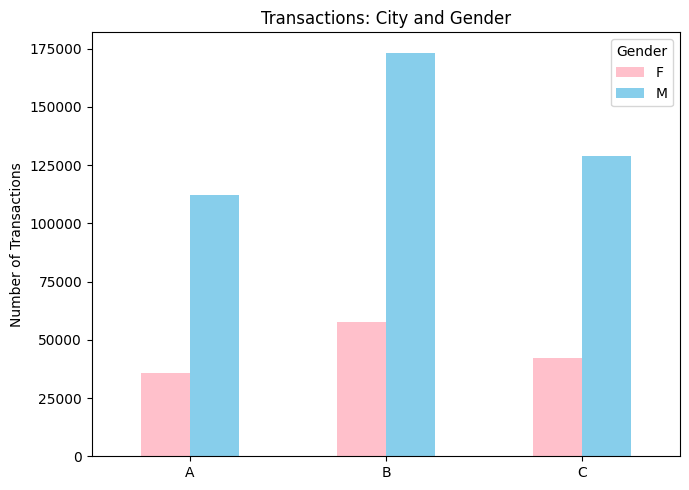

City B + Male is the single largest combination in the dataset.

Logistics insight:
The City B warehouse, specifically the male-product zone, is the biggest bottleneck.
On Black Friday this zone needs the most staff, fastest conveyor belts,
and the highest restock frequency of any zone in the entire operation.


In [24]:
# We group by both City and Gender at the same time to see the combination

pivot = df_clean.groupby(['City_Category', 'Gender']).size().unstack()

pivot.plot(kind='bar', figsize=(7, 5), color=['pink', 'skyblue'])
plt.title('Transactions: City and Gender')
plt.ylabel('Number of Transactions')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
plt.tight_layout()
plt.show()

print("City B + Male is the single largest combination in the dataset.")
print()
print("Logistics insight:")
print("The City B warehouse, specifically the male-product zone, is the biggest bottleneck.")
print("On Black Friday this zone needs the most staff, fastest conveyor belts,")
print("and the highest restock frequency of any zone in the entire operation.")

### Average Purchase by Age Group

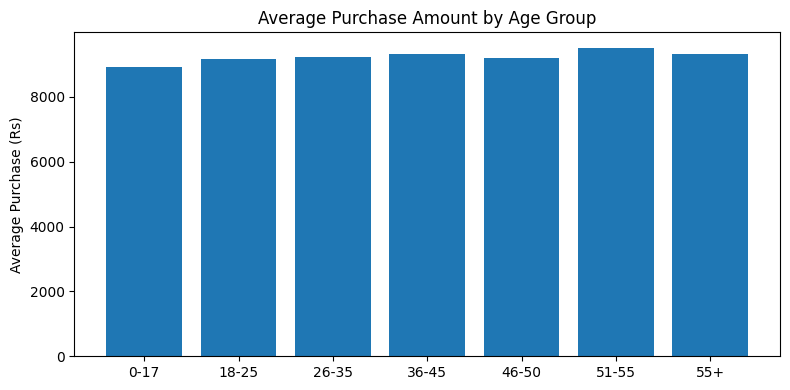

The 55+ age group has the highest average spend per transaction.

Logistics insight:
Older shoppers spend more per trip even though they buy less frequently.
Premium and high-end products need priority pick zones to serve this segment well.


In [25]:
# .groupby('Age') splits the data by age group
# .mean() calculates the average Purchase for each group
# .sort_index() keeps the age groups in order

age_avg = df_clean.groupby('Age')['Purchase'].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(age_avg.index, age_avg.values)
plt.title('Average Purchase Amount by Age Group')
plt.ylabel('Average Purchase (Rs)')
plt.tight_layout()
plt.show()

print("The 55+ age group has the highest average spend per transaction.")
print()
print("Logistics insight:")
print("Older shoppers spend more per trip even though they buy less frequently.")
print("Premium and high-end products need priority pick zones to serve this segment well.")

### Revenue Share by Product Category

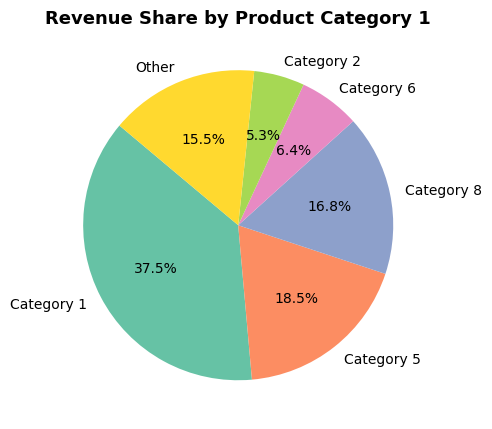

A small number of product categories generate most of the total revenue.

Logistics insight:
These top categories are responsible for the majority of Black Friday income.
They need the most warehouse floor space, the most stock, and the fastest processing.
If these zones run out of stock or slow down, it directly impacts the store's revenue.


In [26]:
# We calculate total revenue generated by each product category
# Then we take the top 5 and group all remaining categories as 'Other'
# This keeps the pie chart readable — too many slices makes it messy

cat_rev  = df_clean.groupby('Product_Category_1')['Purchase'].sum()
top5     = cat_rev.nlargest(5)
other    = pd.Series({'Other': cat_rev[~cat_rev.index.isin(top5.index)].sum()})
pie_data = pd.concat([top5, other])

plt.figure(figsize=(5, 5))
plt.pie(pie_data.values,labels=[f'Category {i}' if i != 'Other' else 'Other' for i in pie_data.index],autopct='%1.1f%%', startangle=140,colors=sns.color_palette('Set2', len(pie_data)))
plt.title('Revenue Share by Product Category 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("A small number of product categories generate most of the total revenue.")
print()
print("Logistics insight:")
print("These top categories are responsible for the majority of Black Friday income.")
print("They need the most warehouse floor space, the most stock, and the fastest processing.")
print("If these zones run out of stock or slow down, it directly impacts the store's revenue.")

### Average Purchase: Marital Status × City

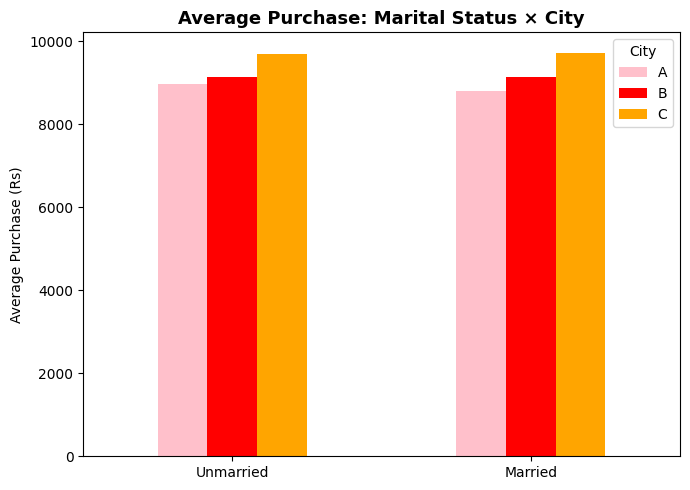

Unmarried shoppers in City C spend the most on average across all combinations.

Logistics insight:
Tier-3 city warehouses should allocate more premium product stock
particularly for single-buyer customer segments.


In [27]:
# We group by two variables at once — Marital_Status and City_Category
# Then we calculate the average purchase for each combination

pivot = df_clean.groupby(['Marital_Status', 'City_Category'])['Purchase'].mean().unstack()
pivot.index = ['Unmarried', 'Married']

pivot.plot(kind='bar', figsize=(7, 5), color=['pink','red','orange'])
plt.title('Average Purchase: Marital Status × City', fontsize=13, fontweight='bold')
plt.ylabel('Average Purchase (Rs)')
plt.xticks(rotation=0)
plt.legend(title='City')
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
plt.tight_layout()
plt.show()

print("Unmarried shoppers in City C spend the most on average across all combinations.")
print()
print("Logistics insight:")
print("Tier-3 city warehouses should allocate more premium product stock")
print("particularly for single-buyer customer segments.")

---
## Week 6 

Feature Engineering

So far we have cleaned the data and explored it visually.
Now we prepare it for machine learning by doing four things:

1. **Encode** text columns into numbers 
models only understand numbers
2. **Transform** the Purchase column using Yeo-Johnson to fix skewness
3. **Create new columns** that directly capture logistics-relevant insights from the data
4. **Scale** all features so no single column dominates the others



In [28]:
# Step 1 — Encode text columns into numbers
# Machine learning models cannot work with text like 'Male' or 'City B'
# We convert every text column to a number

df_eng = df_clean.copy()

In [29]:
# Gender: Female = 0, Male = 1
le = LabelEncoder()
df_eng['Gender_enc'] = le.fit_transform(df_eng['Gender'])
df_eng["Gender_enc"].head()

0    0
1    0
2    0
3    0
4    1
Name: Gender_enc, dtype: int64

In [30]:
# Age: manually mapped to preserve order
# 26-35 must be a HIGHER number than 18-25 so the model understands the age sequence
# LabelEncoder would assign numbers randomly and break that order
age_map = {'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6}
df_eng['Age_enc'] = df_eng['Age'].map(age_map)

In [31]:
# City: A = 0, B = 1, C = 2
df_eng['City_enc'] = le.fit_transform(df_eng['City_Category'])

In [32]:
# Stay in city: '4+' is stored as text because of the plus sign
# Replace with 5 so the whole column becomes numeric
df_eng['Stay_enc'] = df_eng['Stay_In_Current_City_Years'].replace({'4+': 5}).astype(float)

Fix Purchase skewness using Yeo-Johnson transformation

We saw in Week 4 that Purchase is right-skewed
Skewed data causes models to make biased predictions

Why Yeo-Johnson instead of log transform?

Log transform only works on positive values and still leaves some skew
Yeo-Johnson automatically finds the best power transformation for any data
It works on zero, positive, and negative values -more robust and more accurate

PowerTransformer applies it in one line

In [33]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df_eng['Purchase_yj'] = pt.fit_transform(df_eng[['Purchase']])

print(f"Skewness BEFORE Yeo-Johnson : {df_eng['Purchase'].skew():.4f}")
print(f"Skewness AFTER  Yeo-Johnson : {df_eng['Purchase_yj'].skew():.4f}")

Skewness BEFORE Yeo-Johnson : 0.5728
Skewness AFTER  Yeo-Johnson : -0.0403


Skewness closer to 0 = more symmetric = models will give better predictions

### Creating new columns based on what we learned in EDA

### category_breadth


Counts how many category levels describe the product (1, 2, or 3).

In this dataset each row represents a single product purchase.

Product_Category_1 is the main category, while Product_Category_2 and 3

represent deeper subcategory classifications for the same product.

Breadth 1 = product has only a main category

Breadth 2 = product has a main category + one subcategory

Breadth 3 = product has a main category + two subcategories

This helps us understand how specifically the product is classified within the product hierarchy.

In [34]:
df_eng['category_depth'] = ((df_eng['Product_Category_1'] > 0).astype(int) +(df_eng['Product_Category_2'] > 0).astype(int) +(df_eng['Product_Category_3'] > 0).astype(int))
df_eng['category_depth']

0         1
1         3
2         1
3         2
4         1
         ..
550063    1
550064    1
550065    1
550066    1
550067    1
Name: category_depth, Length: 550068, dtype: int64

### is_high_value
We calculate the 80th percentile of the Purchase column and flag

customers whose purchase amount is greater than or equal to that value.

In retail datasets, a small percentage of customers generate a large

portion of total revenue. Identifying high-value purchases helps us study

the behavior of the most valuable transactions during Black Friday.

In [35]:
# Top 20% of spenders flagged as 1, rest as 0
# Based on finding in Week 4: a small group drives most of the revenue
# Logistics use: route instantly to express fulfilment lane — no manual decision needed
df_eng['is_high_value'] = (df_eng['Purchase'] >= df_eng['Purchase'].quantile(0.80)).astype(int)
df_eng['is_high_value']


0         0
1         1
2         0
3         0
4         0
         ..
550063    0
550064    0
550065    0
550066    0
550067    0
Name: is_high_value, Length: 550068, dtype: int64

### multi_category
We check whether Product_Category_2 or Product_Category_3 has a value.

If either exists, we mark the product as belonging to multiple category levels.

This helps identify products that have additional classification layers.

It allows us to compare simple products with more complex product classifications.

In [36]:
df_eng['multi_category'] = (
    (df_eng['Product_Category_2'] > 0) | (df_eng['Product_Category_3'] > 0)
).astype(int)
df_eng['multi_category'] 

0         0
1         1
2         0
3         1
4         0
         ..
550063    0
550064    0
550065    0
550066    0
550067    0
Name: multi_category, Length: 550068, dtype: int64

### is_new_resident
We check the Stay_enc column and mark customers who have lived in the city for 0 or 1 years.

New residents often buy products needed to set up a new home,

such as appliances, furniture, and household items. This feature

helps analyze shopping patterns of recently relocated customers.

In [37]:
# is_new_resident 
# Customers who have lived in their city for 0 or 1 years
# From Week 4 EDA: newer residents shop more they are setting up a new home
# Logistics use: cities with many new residents need extra home-setup product stock
df_eng['is_new_resident'] = (df_eng['Stay_enc'] <= 1).astype(int)
df_eng['is_new_resident']

0         0
1         0
2         0
3         0
4         0
         ..
550063    1
550064    0
550065    0
550066    0
550067    0
Name: is_new_resident, Length: 550068, dtype: int64

### is_young_male

We check two conditions Gender must be M and Age must be 26-35.

If both conditions are true, we assign a value of 1, otherwise 0.

Previous exploratory analysis showed that males aged 26–35

represent one of the largest customer segments in the dataset.

This feature helps analyze the purchasing behavior of this group.

In [38]:
df_eng['is_young_male'] = ((df_eng['Gender'] == 'M') & (df_eng['Age'] == '26-35')).astype(int)
df_eng['is_young_male']

0         0
1         0
2         0
3         0
4         0
         ..
550063    0
550064    0
550065    0
550066    0
550067    0
Name: is_young_male, Length: 550068, dtype: int64

### product_demand
We count how many times each Product_ID appears in the dataset using groupby and transform.

This gives us a measure of product popularity. Products that

appear more frequently in transactions are high-demand items,

which are important for understanding sales patterns during Black Friday.

In [39]:
# product_demand
# Number of times each product appears in transactions

df_eng['product_demand'] = (df_eng.groupby('Product_ID')['Product_ID'].transform('count'))

df_eng['product_demand']

0         227
1         581
2         102
3         341
4         203
         ... 
550063    837
550064    814
550065    814
550066    814
550067    899
Name: product_demand, Length: 550068, dtype: int64

### Customer Purchase Frequency

We counted how many transactions each User_ID has made using groupby and transform.

Some customers make multiple purchases during the sale period.
This feature helps identify frequent shoppers and analyze repeat purchasing behavior.

In [40]:
# user_purchase_frequency
# Number of purchases made by each customer

df_eng['user_purchase_frequency'] = (df_eng.groupby('User_ID')['User_ID'].transform('count'))

df_eng['user_purchase_frequency']

0          35
1          35
2          35
3          35
4          77
         ... 
550063     36
550064    152
550065    514
550066     12
550067     74
Name: user_purchase_frequency, Length: 550068, dtype: int64

### City Purchase Volume

We counted the number of transactions for each City_Category.

Different city types may have different levels of shopping activity.

This feature helps analyze regional demand patterns during Black Friday.

In [41]:
# city_purchase_volume
# Total purchases in each city category

df_eng['city_purchase_volume'] = (
    df_eng.groupby('City_Category')['City_Category'].transform('count')
)

df_eng['city_purchase_volume']

0         147720
1         147720
2         147720
3         147720
4         171175
           ...  
550063    231173
550064    171175
550065    231173
550066    171175
550067    231173
Name: city_purchase_volume, Length: 550068, dtype: int64

In [42]:
df_eng.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase', 'Gender_enc',
       'Age_enc', 'City_enc', 'Stay_enc', 'Purchase_yj', 'category_depth',
       'is_high_value', 'multi_category', 'is_new_resident', 'is_young_male',
       'product_demand', 'user_purchase_frequency', 'city_purchase_volume'],
      dtype='object')

In [43]:
print("New columns created:\n")
print(f"category_depth: min={df_eng['category_depth'].min()}, max={df_eng['category_depth'].max()} levels")

print(f"is_high_value: {df_eng['is_high_value'].sum():,} orders "f"({df_eng['is_high_value'].mean()*100:.1f}%)")

print(f"multi_category: {df_eng['multi_category'].sum():,} orders "f"({df_eng['multi_category'].mean()*100:.1f}%)")

print(f"is_new_resident: {df_eng['is_new_resident'].sum():,} customers "f"({df_eng['is_new_resident'].mean()*100:.1f}%)")

print(f"is_young_male: {df_eng['is_young_male'].sum():,} transactions "f"({df_eng['is_young_male'].mean()*100:.1f}%)")

New columns created:

category_depth: min=1, max=3 levels
is_high_value: 110,048 orders (20.0%)
multi_category: 376,430 orders (68.4%)
is_new_resident: 268,219 customers (48.8%)
is_young_male: 168,835 transactions (30.7%)


### Scaling features

In [ ]:
# Scale all features to the same range

# StandardScaler transforms each column so that
# This ensures that features with large values (like Purchase)
# do not dominate features with smaller ranges (like binary flags).

features = ['Gender_enc', 'Age_enc', 'Occupation', 'City_enc', 'Stay_enc',
            'Marital_Status', 'Product_Category_1', 'Product_Category_2',
            'Product_Category_3', 'Purchase_yj',
            'is_high_value', 'multi_category', 'is_new_resident',
            'is_young_male', 'category_depth']

scaler = StandardScaler()

scaled = scaler.fit_transform(df_eng[features])

df_scaled = pd.DataFrame(scaled,columns=[f'{c}_scaled' for c in features])

print(f"Scaled dataset shape : {df_scaled.shape[0]:,} rows and {df_scaled.shape[1]} columns")
print()
print("Before scaling — Purchase_yj range:")
print(f"  Min: {df_eng['Purchase_yj'].min():.2f},  Max: {df_eng['Purchase_yj'].max():.2f}")
print()
print("After StandardScaler — Purchase_yj_scaled range:")
print(f"  Min: {df_scaled['Purchase_yj_scaled'].min():.2f},  Max: {df_scaled['Purchase_yj_scaled'].max():.2f}")
print()
print("All features are now on the same scale and ready for further analysis.")

Scaled dataset shape : 550,068 rows and 15 columns

Before scaling — Purchase_yj range:
  Min: -2.47,  Max: 1.94

After StandardScaler — Purchase_yj_scaled range:
  Min: -2.47,  Max: 1.94

All features are now on the same scale and ready for further analysis.


### Purchase Before Yeo-Johnson Transform

This is the original Purchase distribution.
The long right tail is the skewness that makes models give biased predictions.

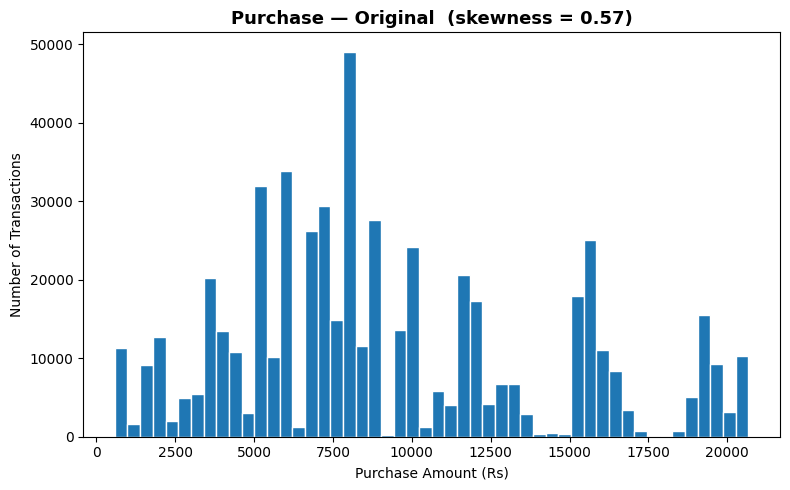

In [45]:
plt.figure(figsize=(8, 5))
plt.hist(df_eng['Purchase'], bins=50, edgecolor='white')
plt.title(f'Purchase — Original  (skewness = {df_eng["Purchase"].skew():.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Purchase Amount (Rs)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

Long tail on the right = right skewed.

This causes demand forecasting models to overestimate average order values.

### Purchase After Yeo-Johnson Transform

After Yeo-Johnson the distribution is much more symmetric.

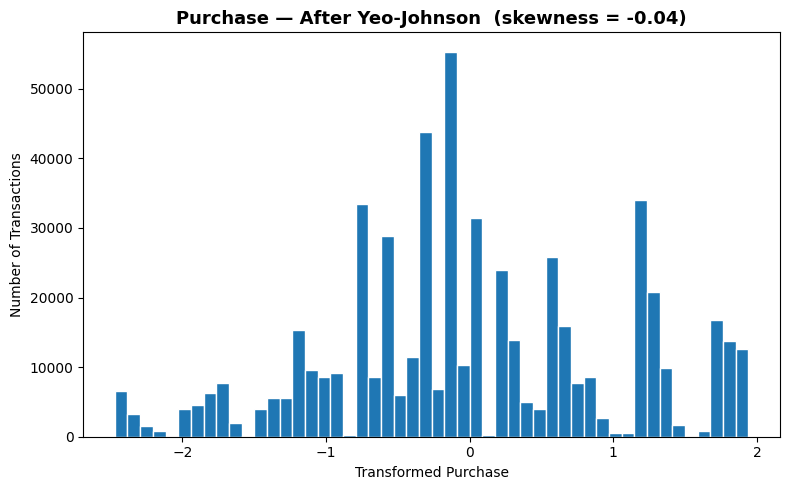

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(df_eng['Purchase_yj'], bins=50, edgecolor='white')
plt.title(f'Purchase — After Yeo-Johnson  (skewness = {df_eng["Purchase_yj"].skew():.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Transformed Purchase')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

Skewness is now close to 0 the distribution is much more symmetric.

Logistics insight: demand forecasts built on this column will be more accurate.

Fewer over-ordering and under-ordering mistakes on Black Friday.

### High-Value Customer Flag

1 in 5 orders is flagged as high-value.
These should automatically go to the express fulfilment lane on Black Friday.

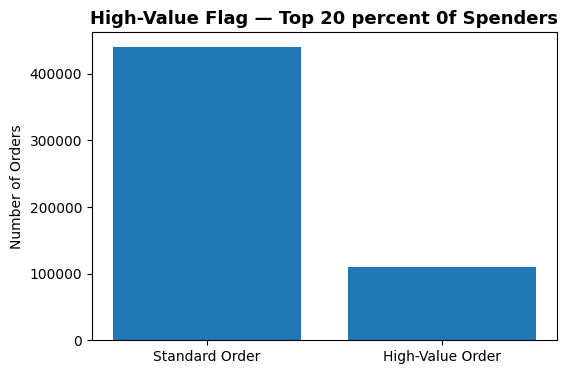

In [47]:
counts = df_eng['is_high_value'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Standard Order', 'High-Value Order'], counts.values)
plt.title('High-Value Flag — Top 20 percent 0f Spenders', fontsize=13, fontweight='bold')
plt.ylabel('Number of Orders')
plt.show()

1 in 5 orders is high-value.

Logistics insight:

With this flag in the data, the system routes these orders to the express lane instantly.

No manual checking needed during the peak Black Friday rush.

### Product Category Depth

This visualization shows how many category levels are used to classify each product.

Products in the dataset can have up to three category levels: 

Product_Category_1 - main category

Product_Category_2 - subcategory

Product_Category_3 - deeper subcategory

Category depth indicates how specifically a product is classified within the retail catalog. Products with greater depth belong to more detailed product groups.

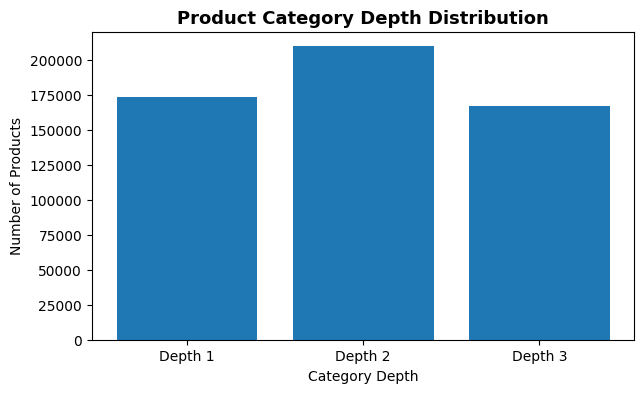

Depth 1 = product has only a main category
Depth 2 = product has a main category and one subcategory
Depth 3 = product has a main category and two subcategories

Insight:
Products with deeper category classification belong to more specific product groups.
This helps understand how products are organized within the retail catalog.


In [48]:
counts = df_eng['category_depth'].value_counts().sort_index()

label_map = {1: 'Depth 1', 2: 'Depth 2', 3: 'Depth 3'}
x_labels  = [label_map[i] for i in counts.index]

plt.figure(figsize=(7,4))
plt.bar(x_labels, counts.values)
plt.title('Product Category Depth Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Products')
plt.xlabel('Category Depth')
plt.show()

print("Depth 1 = product has only a main category")
print("Depth 2 = product has a main category and one subcategory")
print("Depth 3 = product has a main category and two subcategories")
print()
print("Insight:")
print("Products with deeper category classification belong to more specific product groups.")
print("This helps understand how products are organized within the retail catalog.")

### New Resident and Young Male

These two flags identify the most active customer segments from our Week 4 EDA.
Each drives demand for specific product types that need prioritised stocking.

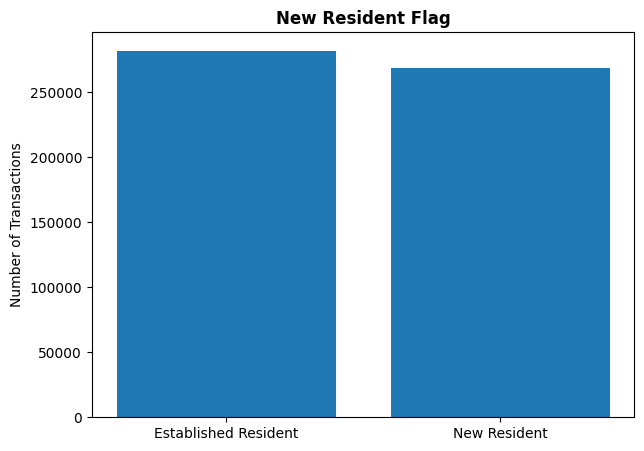

In [49]:
nr = df_eng['is_new_resident'].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(['Established Resident', 'New Resident'], nr.values)

plt.title('New Resident Flag', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions')

plt.show()

Logistics insight for New Residents:

They buy home-setup items like furniture, appliances, and cookware.

Cities with many new residents need higher stock of these categories.

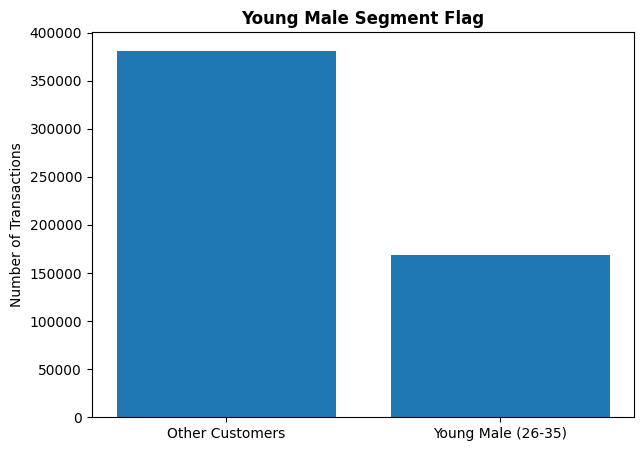

In [50]:
ym = df_eng['is_young_male'].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(['Other Customers', 'Young Male (26-35)'], ym.values)

plt.title('Young Male Segment Flag', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions')

plt.show()

Logistics insight for Young Males (26-35)

This is the single biggest transaction group from our Week 4 analysis

They drive electronics and gadgets demand

The electronics zone needs maximum stock and the fastest picking lanes for this group